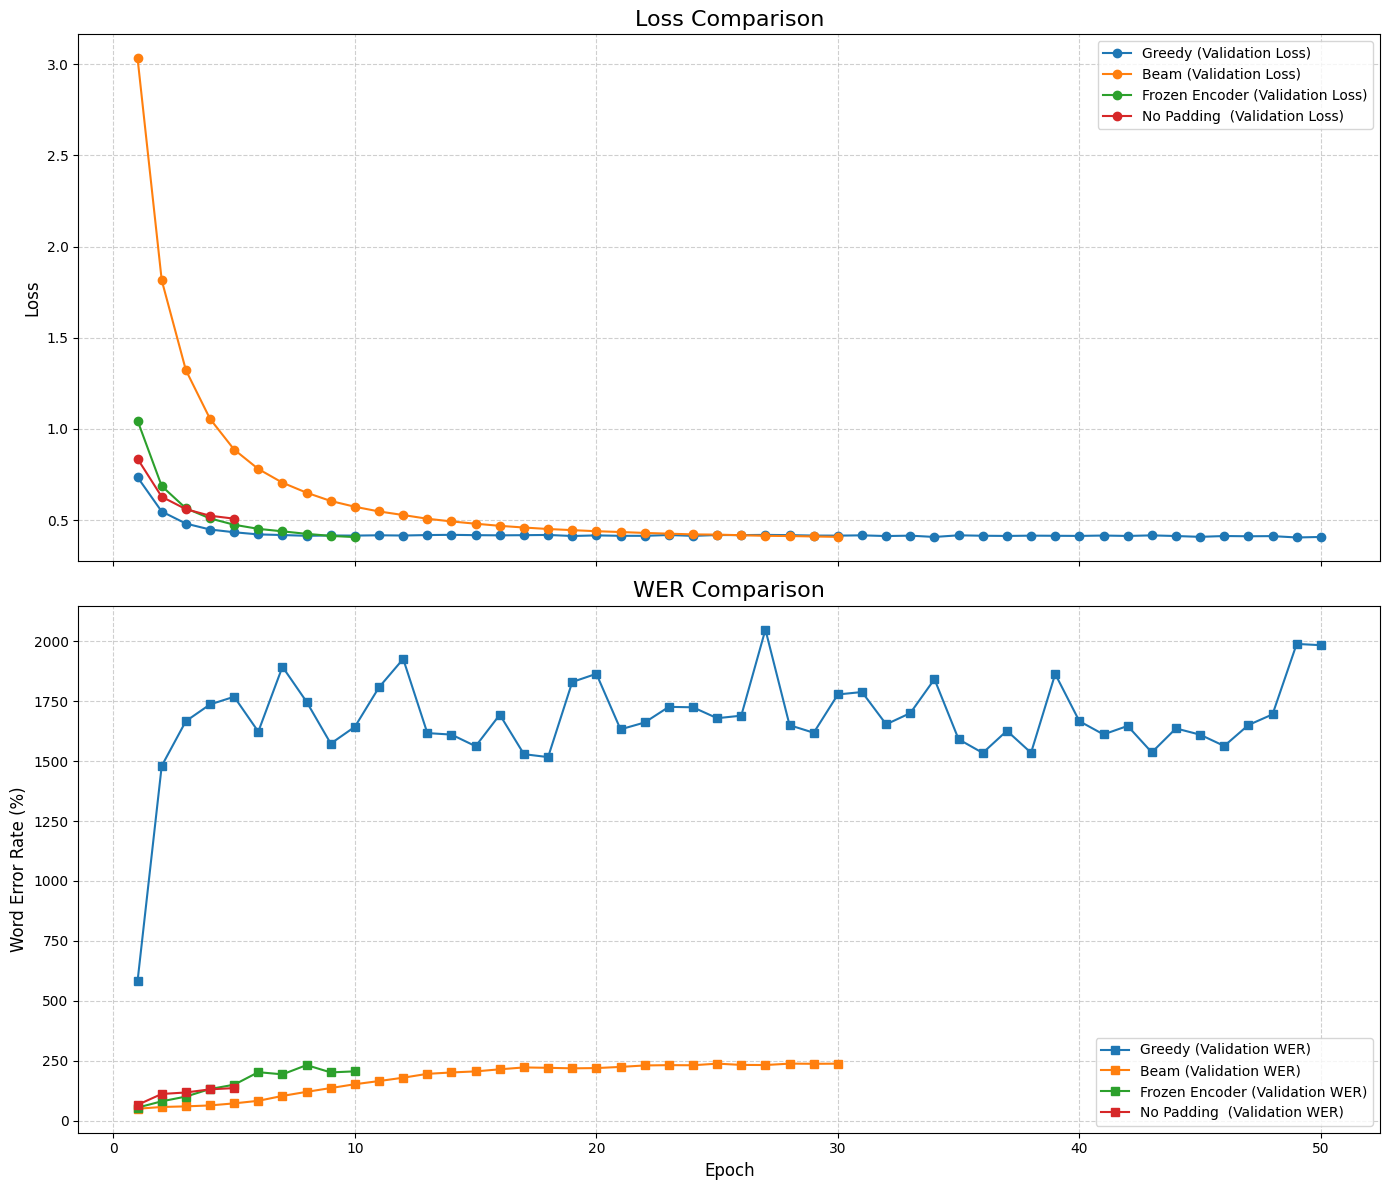

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 設定 ---
# ❗️ training_log_*.csv 檔案放在與此腳本相同的資料夾中

# 定義要比較的日誌檔案和它們在圖例中顯示的名稱
# 我加入了我們在偵錯過程中產生的幾個關鍵版本的日誌檔名
# 若無某個檔案，程式會自動跳過
log_files = {
    "Greedy": "./moonshine/training_log_simplified.csv",
    "Beam": "./moonshine/training_log_simplified_2.csv",
    "Frozen Encoder": "./moonshine/training_log_frozen-encoder.csv",
    "No Padding ": "./moonshine/training_log_no_padding.csv",

}

# --- 繪圖 ---

# 建立一個畫布(figure)，其中包含 2 個子圖(axes)，上下排列
# figsize=(14, 12) 設定圖片大小，讓圖表更清晰
# sharex=True 讓上下兩個子圖共用 X 軸 (Epoch)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

print("正在讀取日誌檔案並繪製曲線...")

# 迭代我們定義的每一個日誌檔案
for label, filename in log_files.items():
    
    # 檢查檔案是否存在，如果不存在就跳過
    if not os.path.exists(filename):
        print(f"⚠️ 警告：找不到檔案 '{filename}'，將跳過。")
        continue

    # 使用 pandas 讀取 CSV 檔案
    df = pd.read_csv(filename)
    
    # --- 繪製 Loss 曲線 (在上方的子圖 ax1) ---
    # 畫出 validation_loss，使用實線
    ax1.plot(df['epoch'], df['validation_loss'], 'o-', label=f'{label} (Validation Loss)')
    
    # --- 繪製 WER 曲線 (在下方的子圖 ax2) ---
    # 將 WER 從比例轉換為百分比
    wer_percent = df['validation_wer'] * 100
    ax2.plot(df['epoch'], wer_percent, 's-', label=f'{label} (Validation WER)')
    
    print(f"✅ 已繪製 '{filename}' 的曲線。")

# --- 設定圖表樣式 ---

# 設定第一個子圖 (Loss) 的樣式
ax1.set_title('Loss Comparison', fontsize=16)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6) # 加入格線
ax1.legend() # 顯示圖例

# 設定第二個子圖 (WER) 的樣式
ax2.set_title('WER Comparison', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Word Error Rate (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# 自動調整版面，避免標籤重疊
plt.tight_layout()

# 儲存圖表為圖片檔案
output_image_path = "training_comparison.png"
plt.savefig(output_image_path, dpi=300)
print(f"\n📈 圖表已儲存至 '{output_image_path}'")

# 顯示圖表
plt.show()